<a href="https://colab.research.google.com/github/L-Carlos/aulas-machine-learning/blob/main/ML_aula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint: Machine Learning & Analytics - PUC Rio (2026)
---
## Aula 2
### Problemas de Regressão

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [35]:
diabetes = load_diabetes()

dataset = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
dataset["target"] = diabetes.target

dataset.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [36]:
X = dataset.drop(columns="target")
y = dataset["target"]

test_size = 0.2
random_seed = 2026

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_seed)

particoes = 10
kfold = KFold(n_splits=particoes, shuffle=True, random_state=random_seed)

In [37]:
np.random.seed(random_seed)


models = [
    {"Name": "LR", "Model": LinearRegression(), "CrossVal": None},
    {"Name": "Ridge", "Model": Ridge(), "CrossVal": None},
    {"Name": "Lasso", "Model": Lasso(), "CrossVal": None},
    {"Name": "KNN", "Model": KNeighborsRegressor(), "CrossVal": None},
    {"Name": "CART", "Model": DecisionTreeRegressor(), "CrossVal": None},
    {"Name": "SVM", "Model": SVR(), "CrossVal": None},
]


for model in models:
    cv_result = cross_val_score(model.get("Model"), X_train, y_train, cv=kfold, scoring="neg_mean_squared_error")
    model["CrossVal"] = cv_result

    print(f"{model.get("Name")}: {model.get("CrossVal").mean():.2f} ({model.get("CrossVal").std():.2f})")



LR: -3089.57 (530.31)
Ridge: -3575.14 (566.80)
Lasso: -4020.11 (747.92)
KNN: -3697.18 (834.77)
CART: -6103.52 (957.58)
SVM: -5135.62 (1177.51)


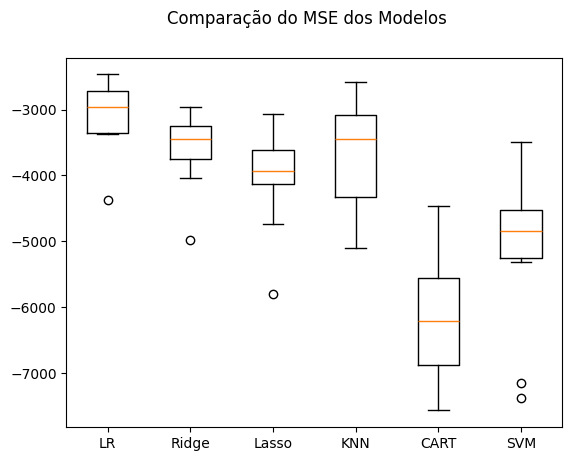

In [38]:
fig = plt.figure()
fig.suptitle('Comparação do MSE dos Modelos')
plt.boxplot(x=[v.get("CrossVal") for v in models], tick_labels=[v.get("Name") for v in models])
plt.show()

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)

f"MSE: {mse:.2f} RMSE {np.sqrt(abs(mse)):.2f}"



'MSE: 2739.10 RMSE 52.34'

In [42]:
dataset.target.describe()

,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000
